*This training is based on Chapter 4 from Hands-On Machine Learning with Scikit-Learn and TensorFlow by Aurélien Géron.*

**Step 1: Import Libraries**

In [14]:
import numpy as np
import PIL
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression


**Step 2: Load and Split Dataset**

In [7]:
X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

**Step 3: Train Logistic Regression Model**

In [8]:
#training on 50 labeled data
n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
#measure accuracy
log_reg.score(X_test, y_test)

0.7581863979848866

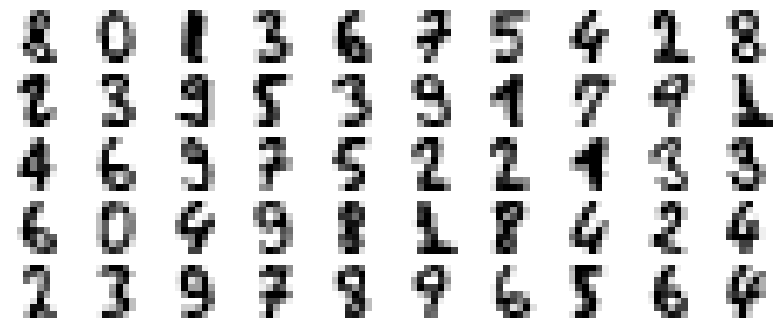

In [15]:
#cluster training set into 50
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]
#visualize data
plt.figure(figsize=(10, 4))
for i, img in enumerate(X_representative_digits):
    plt.subplot(5, 10, i+1)
    plt.imshow(img.reshape(8, 8), cmap="binary")
    plt.axis("off")
plt.show()

In [16]:
#manually label representative images
y_representative_digits = np.array([8, 0, 1, 3, 6, 7, 5, 4, 2, 8, 2, 3, 9, 5, 3,
                                    9, 1, 7, 4, 1, 4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
                                    6, 0, 4, 9, 8, 1, 8, 4, 2, 4, 2, 3, 9, 7, 8,
                                    9, 6, 5, 6,4])

In [17]:
#test performance in hopes of better results
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8413098236775819

In [24]:
#now use label propagation
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
  y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [25]:
#training model one more time
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
#evaluate performance
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8614609571788413